<a href="https://colab.research.google.com/github/tiwarisubash956/Machine-Learning-Algorithms/blob/main/222222Pneumonia_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import os
from google.colab import drive
import zipfile
from pathlib import Path
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
import torchvision
from sklearn.metrics import classification_report,roc_auc_score,confusion_matrix,precision_recall_curve

from torchvision import transforms,datasets,models
import torch
from torch.utils.data import DataLoader,ConcatDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


In [2]:
drive.mount('/content/drive')
datasetpathdrive='/content/drive/MyDrive/Chest X-Ray Images (Pneumonia).zip'

Mounted at /content/drive


In [3]:
with zipfile.ZipFile(datasetpathdrive,'r') as z:
  z.extractall('dataset')

Data loader

In [4]:
train_dataset_path=Path('/content/dataset/chest_xray/chest_xray/train')
test_dataset_path=Path('/content/dataset/chest_xray/chest_xray/test')
validation_dataset_path=Path('/content/dataset/chest_xray/chest_xray/val')



In [5]:

# separate transforms
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

# load train folder twice: once augmented, once plain (for merging + splitting)
train_data_aug = datasets.ImageFolder(root=train_dataset_path, transform=train_transform)
train_data_plain = datasets.ImageFolder(root=train_dataset_path, transform=eval_transform)
val_data_aug = datasets.ImageFolder(root=validation_dataset_path, transform=train_transform)
val_data_plain = datasets.ImageFolder(root=validation_dataset_path, transform=eval_transform)

# merge train + tiny official val, then make our OWN proper val split
full_aug = ConcatDataset([train_data_aug, val_data_aug])
full_plain = ConcatDataset([train_data_plain, val_data_plain])

torch.manual_seed(42)
indices = torch.randperm(len(full_aug)).tolist()
train_size = int(0.85 * len(full_aug))
train_idx, val_idx = indices[:train_size], indices[train_size:]

train_dataset = torch.utils.data.Subset(full_aug, train_idx)     # augmented
validation_dataset = torch.utils.data.Subset(full_plain, val_idx)  # not augmented

# official test set — untouched, used only once at the very end
test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print("train dataset length:", len(train_dataset))
print("validation dataset length:", len(validation_dataset))
print("test dataset length:", len(test_dataset))

train dataset length: 4447
validation dataset length: 785
test dataset length: 624


EDA

In [6]:

class_names = train_data_plain.classes

def get_targets_from_subset(subset):
    """Extract labels from a Subset of a ConcatDataset."""
    concat_dataset = subset.dataset
    indices = subset.indices

    labels = []
    for idx in indices:
        _, label = concat_dataset[idx]
        labels.append(label)
    return labels

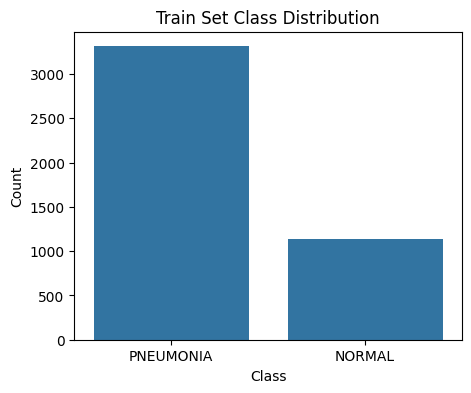

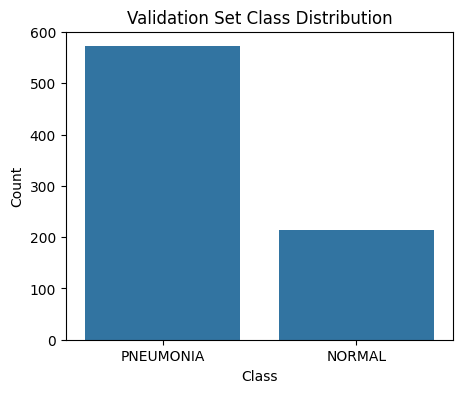

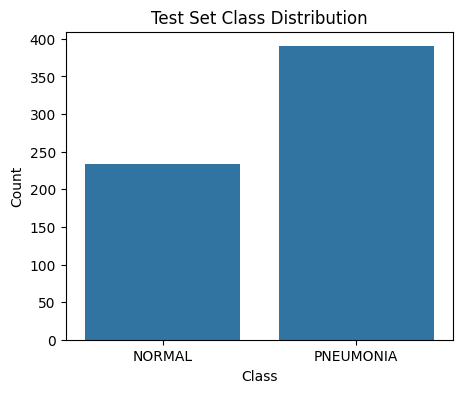

In [7]:
def plot_counts(targets, class_names, title):
    labels = [class_names[t] for t in targets]
    plt.figure(figsize=(5, 4))
    sns.countplot(x=labels)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.show()

all_targets = train_data_plain.targets + val_data_plain.targets
train_targets = [all_targets[i] for i in train_idx]
val_targets = [all_targets[i] for i in val_idx]
test_targets = test_dataset.targets

plot_counts(train_targets, class_names, "Train Set Class Distribution")
plot_counts(val_targets, class_names, "Validation Set Class Distribution")
plot_counts(test_targets, class_names, "Test Set Class Distribution")

In [8]:
class_names=train_data_plain.classes
print(class_names)

targets=np.array(train_data_plain.targets + val_data_plain.targets)
class_counts=np.bincount(targets)
print(class_counts)

class_weights = torch.tensor(1.0 / class_counts, dtype=torch.float).to(device)

['NORMAL', 'PNEUMONIA']
[1349 3883]


In [12]:
def show_images(dataset, class_name, n=50, cols=10):
    rows = (n + cols - 1) // cols
    plt.figure(figsize=(cols * 1.5, rows * 1.5))

    indices = random.sample(range(len(dataset)), n)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    for plot_i, idx in enumerate(indices):
        image, label = dataset[idx]

        # Undo normalization
        image = image * std + mean

        # Convert CHW → HWC
        img = image.numpy().transpose((1, 2, 0))

        # Make sure values are between 0 and 1
        img = img.clip(0, 1)

        plt.subplot(rows, cols, plot_i + 1)
        plt.imshow(img)
        plt.title(class_name[label])
        plt.axis('off')

    plt.tight_layout()
    plt.show()

['NORMAL', 'PNEUMONIA']


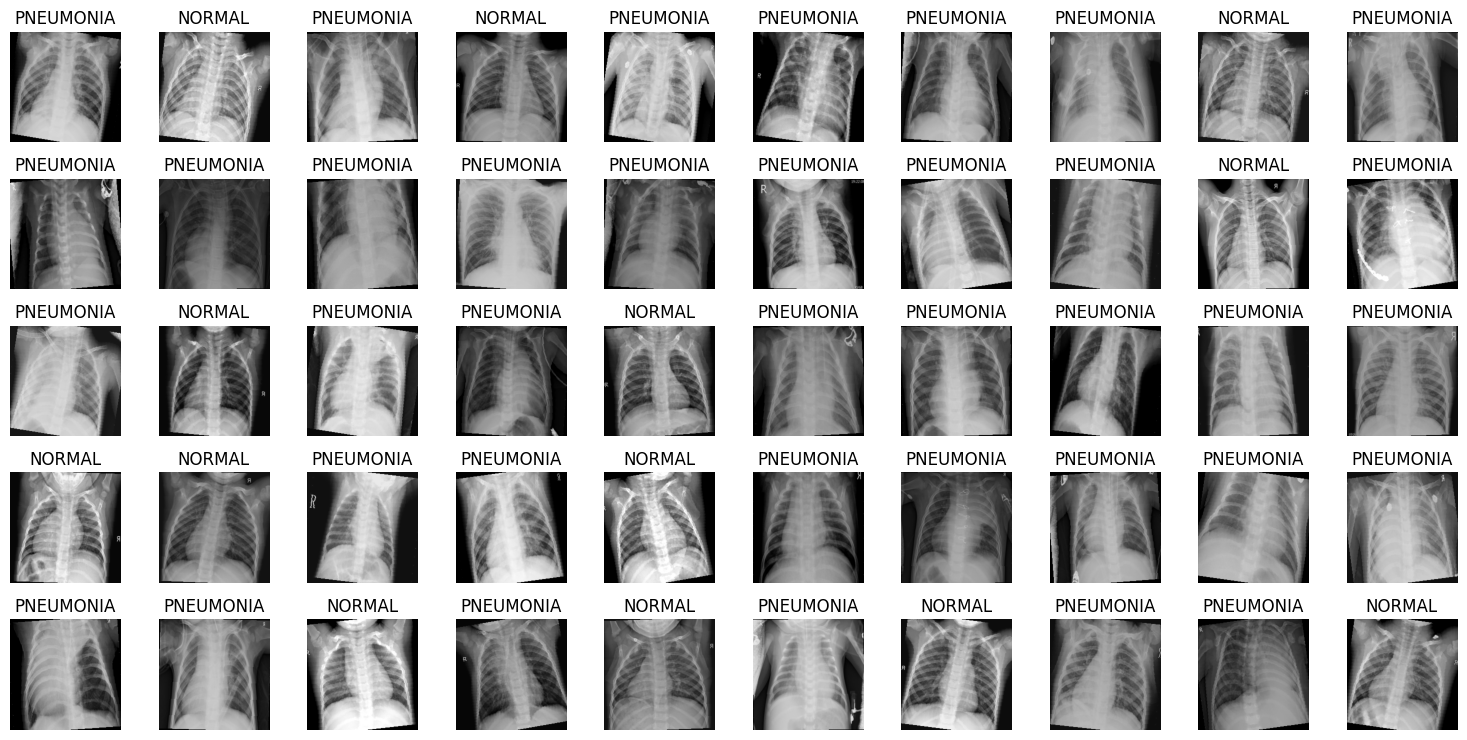

In [13]:
# images of train data
class_name=train_data_aug.classes
print(class_name)
show_images(train_data_aug,class_name)

['NORMAL', 'PNEUMONIA']


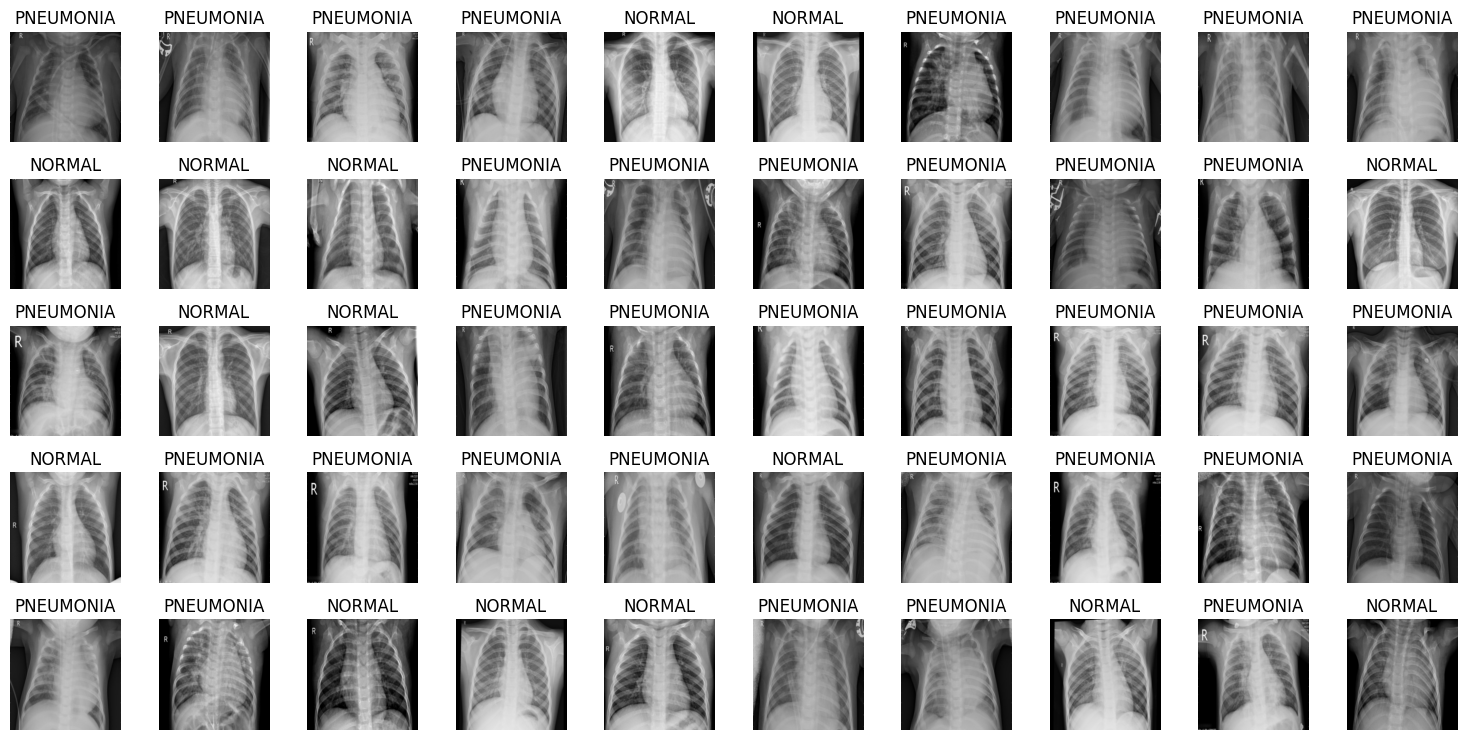

In [14]:
# images of test data
class_name=test_dataset.classes
print(class_name)
show_images(test_dataset,class_name)

**Modeling**

In [16]:
model=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
for param in model.parameters():
    param.requires_grad = False
model.fc=nn.Linear(model.fc.in_features,2)
model.to(device)

criterion=nn.CrossEntropyLoss(weight=class_weights)
optimizer=optim.Adam(model.parameters(),lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


In [17]:

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)[:, 1]
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    return running_loss / total, correct / total, all_preds, all_labels, all_probs


In [18]:
num_epochs = 15
best_val_loss = float("inf")
patience, patience_counter = 3, 0

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _, _ = evaluate(model, validation_loader, criterion)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_model.pth")
        print("  -> Saved new best model")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("Early stopping triggered")
            break

Epoch 1/15 | Train Loss: 0.3905 Acc: 0.8347 | Val Loss: 0.2632 Acc: 0.8611
  -> Saved new best model
Epoch 2/15 | Train Loss: 0.2436 Acc: 0.9026 | Val Loss: 0.2686 Acc: 0.8586
Epoch 3/15 | Train Loss: 0.2011 Acc: 0.9274 | Val Loss: 0.3413 Acc: 0.8166
Epoch 4/15 | Train Loss: 0.1795 Acc: 0.9307 | Val Loss: 0.1815 Acc: 0.9248
  -> Saved new best model
Epoch 5/15 | Train Loss: 0.1779 Acc: 0.9314 | Val Loss: 0.1791 Acc: 0.9236
  -> Saved new best model
Epoch 6/15 | Train Loss: 0.1616 Acc: 0.9404 | Val Loss: 0.2108 Acc: 0.9019
Epoch 7/15 | Train Loss: 0.1657 Acc: 0.9364 | Val Loss: 0.1770 Acc: 0.9261
  -> Saved new best model
Epoch 8/15 | Train Loss: 0.1561 Acc: 0.9391 | Val Loss: 0.1938 Acc: 0.9172
Epoch 9/15 | Train Loss: 0.1640 Acc: 0.9384 | Val Loss: 0.1712 Acc: 0.9312
  -> Saved new best model
Epoch 10/15 | Train Loss: 0.1532 Acc: 0.9384 | Val Loss: 0.2004 Acc: 0.9121
Epoch 11/15 | Train Loss: 0.1681 Acc: 0.9355 | Val Loss: 0.1668 Acc: 0.9338
  -> Saved new best model
Epoch 12/15 | Tra

Evaluation

In [25]:
model.load_state_dict(torch.load("best_model.pth"))
test_loss, test_acc, preds, labels, probs = evaluate(model, test_loader, criterion)

print(f"Test Accuracy: {test_acc:.4f}")
print(classification_report(labels, preds, target_names=class_names))
print("AUC-ROC:", roc_auc_score(labels, probs))
print("Confusion Matrix:\n", confusion_matrix(labels, preds))

Test Accuracy: 0.8830
              precision    recall  f1-score   support

      NORMAL       0.94      0.74      0.82       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624

AUC-ROC: 0.9504054350208196
Confusion Matrix:
 [[172  62]
 [ 11 379]]


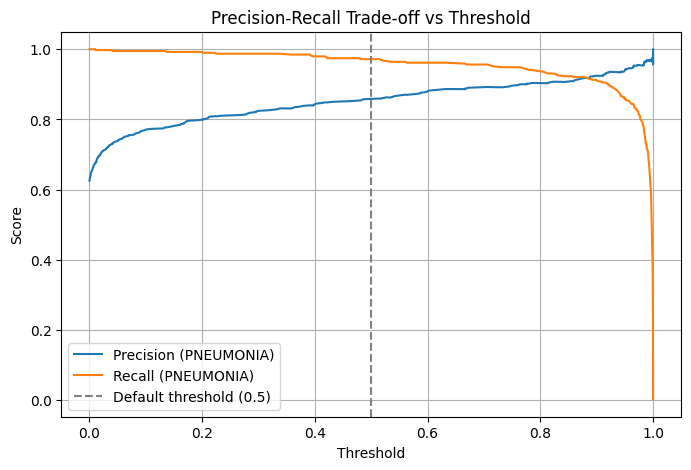

In [28]:


labels = np.array(labels)
probs = np.array(probs)

precision, recall, thresholds = precision_recall_curve(labels, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precision[:-1], label="Precision (PNEUMONIA)")
plt.plot(thresholds, recall[:-1], label="Recall (PNEUMONIA)")
plt.axvline(x=0.5, color='gray', linestyle='--', label="Default threshold (0.5)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off vs Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

def evaluate_at_threshold(labels, probs, threshold, class_names):
    preds = (probs >= threshold).astype(int)
    print(f"\n--- Threshold = {threshold} ---")
    print(classification_report(labels, preds, target_names=class_names))
    print("Confusion Matrix:\n", confusion_matrix(labels, preds))

for t in [0.5, 0.55, 0.6, 0.65, 0.7]:
    evaluate_at_threshold(labels, probs, t, class_names)


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

      NORMAL       0.94      0.74      0.82       234
   PNEUMONIA       0.86      0.97      0.91       390

    accuracy                           0.88       624
   macro avg       0.90      0.85      0.87       624
weighted avg       0.89      0.88      0.88       624

Confusion Matrix:
 [[172  62]
 [ 11 379]]

--- Threshold = 0.55 ---
              precision    recall  f1-score   support

      NORMAL       0.93      0.76      0.83       234
   PNEUMONIA       0.87      0.96      0.91       390

    accuracy                           0.89       624
   macro avg       0.90      0.86      0.87       624
weighted avg       0.89      0.89      0.88       624

Confusion Matrix:
 [[177  57]
 [ 14 376]]

--- Threshold = 0.6 ---
              precision    recall  f1-score   support

      NORMAL       0.92      0.79      0.85       234
   PNEUMONIA       0.88      0.96      0.92       390

    accuracy          